# Stage 4: Proper Evaluation

Here we evaluate Logistic Regression more rigorously.

In [1]:
import json
import sys
from pathlib import Path
import matplotlib.pyplot as plt

sys.path.append("../src")
from issue_intelligence.models.classical import build_classical_pipeline
from issue_intelligence.evaluation import compute_metrics, plot_confusion_matrix, extract_errors

from sklearn import set_config
set_config(display='text')

DATA_DIR = Path("../data/processed")


## 1. Load Data (Stratified and Temporal)

In [2]:
def load_data(file_path):
    X, y = [], []
    if not file_path.exists():
        return X, y
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            r = json.loads(line)
            X.append(r.get("combined_text", ""))
            y.append(r.get("target", "Unknown"))
    return X, y

X_train_strat, y_train_strat = load_data(DATA_DIR / "scikit-learn_issues_model_stratified_train.jsonl")
X_test_strat, y_test_strat = load_data(DATA_DIR / "scikit-learn_issues_model_stratified_test.jsonl")

X_train_temp, y_train_temp = load_data(DATA_DIR / "scikit-learn_issues_model_temporal_train.jsonl")
X_test_temp, y_test_temp = load_data(DATA_DIR / "scikit-learn_issues_model_temporal_test.jsonl")


## 2. Train Logistic Regression

In [3]:
print("Training on Stratified Split...")
model_strat = build_classical_pipeline("logistic_regression")
model_strat.fit(X_train_strat, y_train_strat)

print("Training on Temporal Split...")
model_temp = build_classical_pipeline("logistic_regression")
model_temp.fit(X_train_temp, y_train_temp)


Training on Stratified Split...
Training on Temporal Split...


Pipeline(steps=[('tfidf',
                 TfidfVectorizer(max_df=0.95, max_features=10000, min_df=2,
                                 ngram_range=(1, 2), stop_words='english',
                                 strip_accents='unicode')),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

## 3. Evaluate and Confusion Matrix

Stratified Macro F1: 1.0000


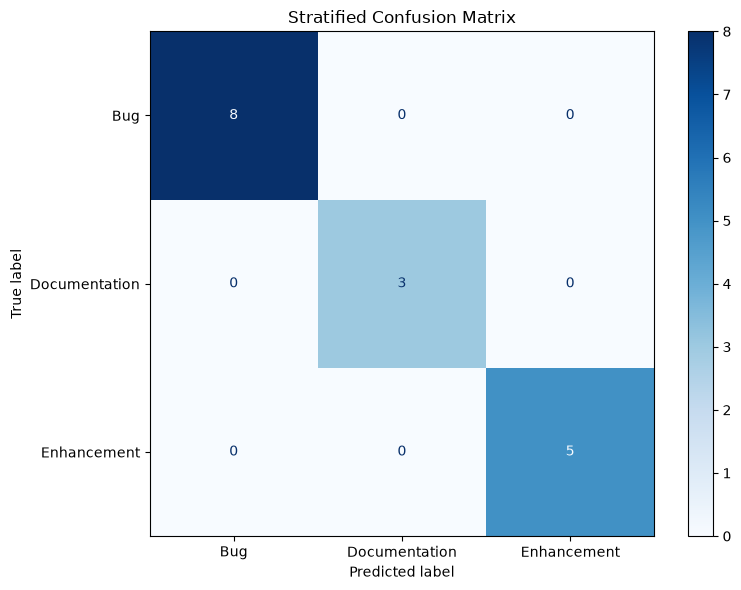

Temporal Macro F1: 1.0000


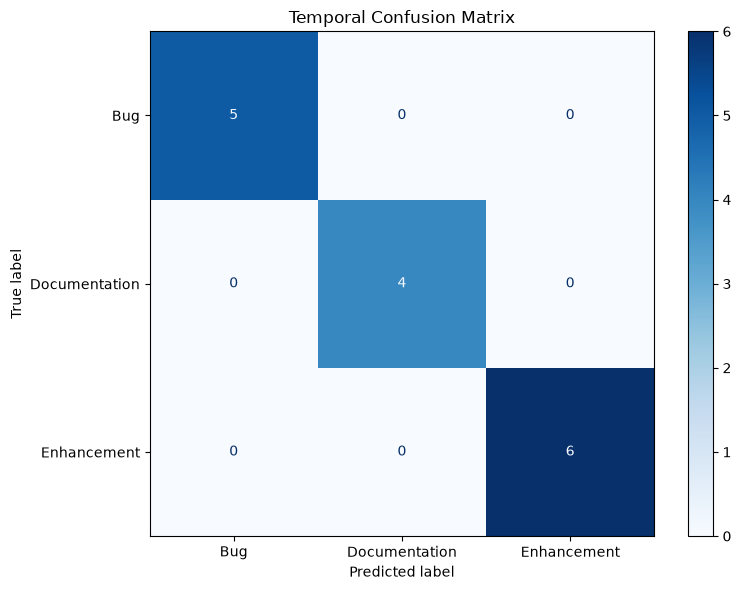

In [4]:
y_pred_strat = model_strat.predict(X_test_strat)
metrics_strat = compute_metrics(y_test_strat, y_pred_strat)
print(f"Stratified Macro F1: {metrics_strat['macro avg']['f1-score']:.4f}")

fig = plot_confusion_matrix(y_test_strat, y_pred_strat)
plt.title("Stratified Confusion Matrix")
plt.show()

y_pred_temp = model_temp.predict(X_test_temp)
metrics_temp = compute_metrics(y_test_temp, y_pred_temp)
print(f"Temporal Macro F1: {metrics_temp['macro avg']['f1-score']:.4f}")

fig2 = plot_confusion_matrix(y_test_temp, y_pred_temp)
plt.title("Temporal Confusion Matrix")
plt.show()


## 4. Error Analysis

In [5]:
errors = extract_errors(X_test_strat, y_test_strat, y_pred_strat)
print(f"Total Errors in Stratified Test: {len(errors)}")
print("Sample of 3 errors:\n")
for e in errors[:3]:
    print(f"TRUE: {e['true_label']} | PRED: {e['predicted_label']}")
    print(f"TEXT: {e['text'][:150]}...")
    print("-" * 50)


Total Errors in Stratified Test: 0
Sample of 3 errors:

